In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skbio.diversity.alpha import shannon
from scipy.stats import zscore
from scipy.stats import ttest_ind

In [3]:
###Define Thresholds
rare_species_definition_threshold = 0.1
rare_species_abundance_threshold = 6.5
expressed_gene_reads_threshold = 2000
number_of_samples_expressed_in_threshold = 21

In [4]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()

metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)

metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples

raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_for_norm.csv",
    index_col=0,
)

trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)
trimmed_raw_transcriptome = raw_transcriptome.drop(index=all_unsable)
trimmed_metadata = trimmed_metadata.sort_index()
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=0)
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=1)
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)

In [5]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.0,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.0,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.0,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,0.0,6.130092,4.215597,0.0,0.0,19.379509,0.0,5.006570,...,16.219201,43.599301,0.0,0.000000,0.0,0.0,1.074213,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,0.074367,4.474710,0.0,1.383813,2.059206,0.0,0.0,27.907884,0.0,11.118408,...,3.486989,4.209645,0.0,1.072920,0.0,0.0,0.948096,0.0,0.000000,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.0,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H10,0.000000,0.000000,0.0,0.000000,2.953706,0.0,0.0,36.084398,0.0,0.000000,...,0.000000,4.975538,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.0,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222


In [5]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1,LIC522,Circadian Experiment 1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12281,LIC122,plant,t11,12/15/23,8:00,LIC_02,44,LIC122,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 hankookensis,0.5,LIC122,Long Term
12282,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term
12283,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5,LIC631,Circadian Experiment 2
12284,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5,LIC629,Circadian Experiment 2


In [6]:
species_abundance_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True
...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False
275,Telluria timonae,1,10.800000,10.80,0.002688,False
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False


In [7]:
species_abundance_table["rare"] = False
species_abundance_table.loc[
    species_abundance_table["n_samples_present"] <= 37, "rare"
] = True
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core,rare
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True,False
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True,False
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True,False
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True,False
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True,False
...,...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False,True
275,Telluria timonae,1,10.800000,10.80,0.002688,False,True
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False,True
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False,True


In [9]:
list_of_rare_species = species_abundance_table.loc[
    species_abundance_table["rare"] == True, "Species"
].tolist()
list_of_core_species = species_abundance_table.loc[
    species_abundance_table["core"] == True, "Species"
].tolist()
list_of_rare_species

['Bradyrhizobium sp000938255',
 'Noviherbaspirillum_A_568104 psychrotolerans',
 'Brevundimonas huaxiensis',
 'Mycobacterium paragordonae',
 'Aeromicrobium sp001426485',
 'Marmoricola_A_392027 sp001424755',
 'Flavobacterium sangjuense',
 'Herbaspirillum robiniae',
 'Hylemonella sp001432305',
 'Telluria mixta',
 'Undibacterium arcticum',
 'Brevundimonas sp001424025',
 'Herminiimonas arsenicoxydans',
 'Amnibacterium kyonggiense',
 'Patulibacter minatonensis',
 'Aquabacterium_A_592457 parvum',
 'Chioneia frigida',
 'Curtobacterium sp001422205',
 'Kineosporia rhamnosa',
 'Pseudonocardia hierapolitana',
 'Nakamurella panacisegetis',
 'Curvibacter gracilis',
 'Agrobacterium rubi',
 'Nocardioides_A_392796 ginsengisegetis',
 'Pseudoduganella namucuonensis',
 'Pseudomonas_E_647464 rhizosphaerae',
 'Actinoplanes rectilineatus',
 'Microbacterium_A_383321 testaceum_F',
 'Actinoplanes globisporus',
 'Herbaspirillum seropedicae',
 'Methylophilus methylotrophus',
 'Pseudomonas_E_647626 sp900573885',
 

In [10]:
# For each sample, check if it has any rare species or is lacking any core species
rare_species_set = set(list_of_rare_species)
core_species_set = set(list_of_core_species)

# Get species-level summaries for each sample (using sampID from long_term_microbiome)
sample_species = long_term_microbiome.groupby("sampID")["Species"].apply(set)
sample_timepoint = long_term_microbiome.groupby("sampID")["timepoint"].first()
total_species_present = sample_species.apply(len)
core_species_present_count = sample_species.apply(
    lambda species: len(species & core_species_set)
)

# Compute Shannon diversity from each sample's species abundance profile
sample_shannon = (
    long_term_microbiome.loc[:, ["sampID", "Species", "AbundR100"]]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(0.0)
    )
    .groupby(["sampID", "Species"], sort=False)["AbundR100"]
    .sum()
    .groupby(level=0, sort=False)
    .apply(lambda abundances: shannon(abundances.to_numpy()))
    .rename("shannon_diversity")
)

# Check if sample has any rare species
has_rare_species = sample_species.apply(lambda x: len(x & rare_species_set) > 0)

# Check if sample is lacking any core species (missing at least one core species)
lacking_core_species = sample_species.apply(lambda x: not core_species_set.issubset(x))

# Total relative abundance of rare species per sample (sum of AbundR100 over rare species)
rare_abund_by_sample = (
    long_term_microbiome.loc[
        long_term_microbiome["Species"].isin(rare_species_set),
        ["sampID", "AbundR100"],
    ]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(
            0.0
        )  ##Junky column that just makes sure that its numeric
    )
    .groupby("sampID", sort=False)["AbundR100"]
    .sum()
    .rename("rare_species_total_abundR100")
)

# Add columns to metadata using the sampID column (not the index)
trimmed_metadata["timepoint"] = trimmed_metadata["sampID"].map(sample_timepoint)
trimmed_metadata["shannon_diversity"] = (
    trimmed_metadata["sampID"].map(sample_shannon).fillna(0.0)
)
trimmed_metadata["total_species_present"] = trimmed_metadata["sampID"].map(
    lambda sample_id: int(total_species_present.get(sample_id, 0))
)
trimmed_metadata["n_core_species_present"] = trimmed_metadata["sampID"].map(
    lambda sample_id: int(core_species_present_count.get(sample_id, 0))
)
trimmed_metadata["has_rare_species"] = trimmed_metadata["sampID"].map(
    lambda sample_id: bool(has_rare_species.get(sample_id, False))
)
trimmed_metadata["lacking_core_species"] = trimmed_metadata["sampID"].map(
    lambda sample_id: bool(lacking_core_species.get(sample_id, True))
)
trimmed_metadata["rare_species_total_abundR100"] = (
    trimmed_metadata["sampID"].map(rare_abund_by_sample).fillna(0.0)
)

trimmed_metadata[
    [
        "sampID",
        "timepoint",
        "shannon_diversity",
        "total_species_present",
        "n_core_species_present",
        "has_rare_species",
        "lacking_core_species",
        "rare_species_total_abundR100",
    ]
]

,sampID,timepoint,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,,,,,
A2449446903_n01_LICRNA02_A01,LIC157,t14,3.566500,54,10,True,False,13.5
A2449446903_n01_LICRNA02_A02,LIC169,t15,2.268220,21,9,True,True,0.7
A2449446903_n01_LICRNA02_A03,LIC193,t17,2.409302,28,10,True,False,1.7
A2449446903_n01_LICRNA02_A05,LIC217,t19,2.914743,35,10,True,False,1.0
A2449446903_n01_LICRNA02_A06,LIC229,t20,2.849462,37,9,True,True,5.0
...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,LIC428,c1_t04,1.536957,17,9,False,True,0.0
B250508004_n01_LICRNA03_H09,LIC440,c1_t05,2.330638,22,10,False,False,0.0
B250508004_n01_LICRNA03_H10,LIC452,c1_t06,1.516584,18,8,True,True,1.0


In [11]:
trimmed_metadata["Dysbiosis Status"] = "Not Dysbiotic"
trimmed_metadata.loc[
    trimmed_metadata["rare_species_total_abundR100"] > rare_species_abundance_threshold,
    "Dysbiosis Status",
] = "Dysbiotic"
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,Sample Month,daysincestart,Date and Time,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100,Dysbiosis Status
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,January,83,2024-01-23 08:00:00,3.566500,54,10,True,False,13.5,Dysbiotic
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,January,87,2024-01-27 08:00:00,2.268220,21,9,True,True,0.7,Not Dysbiotic
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,February,93,2024-02-02 08:00:00,2.409302,28,10,True,False,1.7,Not Dysbiotic
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,February,100,2024-02-09 08:00:00,2.914743,35,10,True,False,1.0,Not Dysbiotic
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,February,107,2024-02-16 08:00:00,2.849462,37,9,True,True,5.0,Not Dysbiotic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,February,101,2024-02-10 08:00:00,1.536957,17,9,False,True,0.0,Not Dysbiotic
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,February,101,2024-02-10 12:00:00,2.330638,22,10,False,False,0.0,Not Dysbiotic
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,February,101,2024-02-10 16:00:00,1.516584,18,8,True,True,1.0,Not Dysbiotic


In [17]:
defense_gene_list

,gene
0,AT1G01100
1,AT1G01230
2,AT1G04510
3,AT1G07360
4,AT1G08450
...,...
194,AT5G64810
195,AT5G65200
196,AT5G67300
197,AT5G67330


In [12]:
transcriptome_in_defense_gene_list = trimmed_transcriptome.loc[
    :, trimmed_transcriptome.columns.isin(defense_gene_list["gene"].tolist())
]
summed_zscored_transcriptome = (
    transcriptome_in_defense_gene_list.apply(zscore).sum(axis=1) / 199
)
circadian_metadata_w_load_info = trimmed_metadata.merge(
    summed_zscored_transcriptome.rename("Summed Defense Z Score"),
    left_index=True,
    right_index=True,
)

In [27]:
circadian_metadata_w_load_info

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,daysincestart,Date and Time,Dysbiosis Status,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100,Summed Defense Z Score
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,83,2024-01-23 08:00:00,Dysbiotic,3.566500,54,10,True,False,13.5,0.781003
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,87,2024-01-27 08:00:00,Not Dysbiotic,2.268220,21,9,True,True,0.7,-0.228172
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,93,2024-02-02 08:00:00,Not Dysbiotic,2.409302,28,10,True,False,1.7,-0.183699
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,100,2024-02-09 08:00:00,Not Dysbiotic,2.914743,35,10,True,False,1.0,0.910173
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,107,2024-02-16 08:00:00,Not Dysbiotic,2.849462,37,9,True,True,5.0,-0.071228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,101,2024-02-10 08:00:00,Not Dysbiotic,1.536957,17,9,False,True,0.0,-0.561195
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,101,2024-02-10 12:00:00,Not Dysbiotic,2.330638,22,10,False,False,0.0,-0.031618
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,101,2024-02-10 16:00:00,Not Dysbiotic,1.516584,18,8,True,True,1.0,-0.069840


In [29]:
circadian_metadata_w_load_info.groupby("Dysbiosis Status")[
    "Summed Defense Z Score"
].mean()

Dysbiosis Status
Dysbiotic        0.208797
Not Dysbiotic   -0.056879
Name: Summed Defense Z Score, dtype: float64

In [31]:
dysbiotic_scores = circadian_metadata_w_load_info.loc[
    circadian_metadata_w_load_info["Dysbiosis Status"] == "Dysbiotic",
    "Summed Defense Z Score",
]
nondysbiotic_scores = circadian_metadata_w_load_info.loc[
    circadian_metadata_w_load_info["Dysbiosis Status"] == "Not Dysbiotic",
    "Summed Defense Z Score",
]

In [33]:
nondysbiotic_scores

filename
A2449446903_n01_LICRNA02_A02   -0.228172
A2449446903_n01_LICRNA02_A03   -0.183699
A2449446903_n01_LICRNA02_A05    0.910173
A2449446903_n01_LICRNA02_A06   -0.071228
A2449446903_n01_LICRNA02_A07   -0.085355
                                  ...   
B250508004_n01_LICRNA03_H08    -0.561195
B250508004_n01_LICRNA03_H09    -0.031618
B250508004_n01_LICRNA03_H10    -0.069840
B250508004_n01_LICRNA03_H11     0.466663
B250508004_n01_LICRNA03_H12    -0.204114
Name: Summed Defense Z Score, Length: 290, dtype: float64

In [32]:
dysbiotic_scores

filename
A2449446903_n01_LICRNA02_A01    0.781003
A2449446903_n01_LICRNA02_B02   -0.484234
A2449446903_n01_LICRNA02_C07    0.039775
A2449446903_n01_LICRNA02_C12   -0.387963
A2449446903_n01_LICRNA02_D07   -0.519182
                                  ...   
B250508004_n01_LICRNA03_F03    -0.023008
B250508004_n01_LICRNA03_F12    -0.200570
B250508004_n01_LICRNA03_G01    -0.418587
B250508004_n01_LICRNA03_G04    -0.163808
B250508004_n01_LICRNA03_G05    -0.443419
Name: Summed Defense Z Score, Length: 79, dtype: float64

In [34]:
ttest_ind(a=dysbiotic_scores, b=nondysbiotic_scores)

TtestResult(statistic=np.float64(3.5480663557290115), pvalue=np.float64(0.0004384251348818269), df=np.float64(367.0))

<Axes: xlabel='Dysbiosis Status', ylabel='Summed Defense Z Score'>

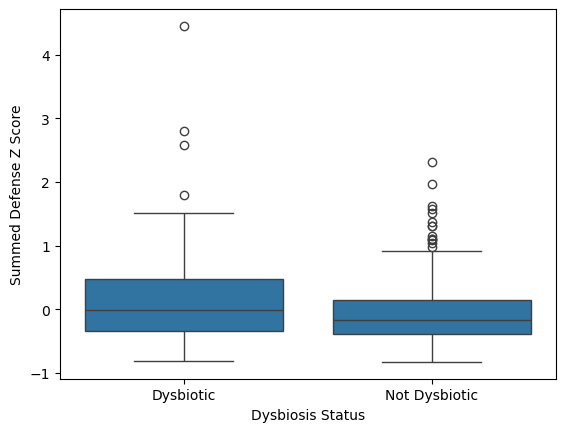

In [28]:
sns.boxplot(
    data=circadian_metadata_w_load_info,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
)

In [44]:
circadian_metadata_w_load_info

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,daysincestart,Date and Time,Dysbiosis Status,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100,Summed Defense Z Score
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,83,2024-01-23 08:00:00,Dysbiotic,3.566500,54,10,True,False,13.5,0.781003
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,87,2024-01-27 08:00:00,Not Dysbiotic,2.268220,21,9,True,True,0.7,-0.228172
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,93,2024-02-02 08:00:00,Not Dysbiotic,2.409302,28,10,True,False,1.7,-0.183699
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,100,2024-02-09 08:00:00,Not Dysbiotic,2.914743,35,10,True,False,1.0,0.910173
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,107,2024-02-16 08:00:00,Not Dysbiotic,2.849462,37,9,True,True,5.0,-0.071228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,101,2024-02-10 08:00:00,Not Dysbiotic,1.536957,17,9,False,True,0.0,-0.561195
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,101,2024-02-10 12:00:00,Not Dysbiotic,2.330638,22,10,False,False,0.0,-0.031618
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,101,2024-02-10 16:00:00,Not Dysbiotic,1.516584,18,8,True,True,1.0,-0.069840


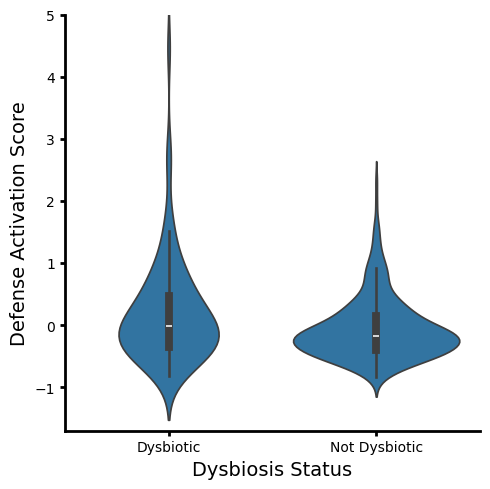

In [72]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=circadian_metadata_w_load_info,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
    inner="box",
    common_norm=True,
)
plt.xlabel("Dysbiosis Status", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-1.7, 5)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

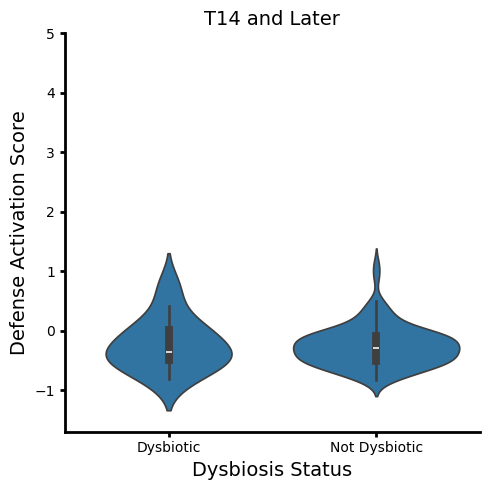

In [13]:
t14_and_later = circadian_metadata_w_load_info.loc[
    pd.to_numeric(
        circadian_metadata_w_load_info["timepoint"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )
    >= 14
]

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=t14_and_later,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
    inner="box",
    common_norm=True,
)
plt.xlabel("Dysbiosis Status", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
plt.title("T14 and Later", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-1.7, 5)
plt.tight_layout()

In [17]:
t14_and_later.groupby("Dysbiosis Status")["Summed Defense Z Score"].count()

Dysbiosis Status
Dysbiotic         14
Not Dysbiotic    103
Name: Summed Defense Z Score, dtype: int64

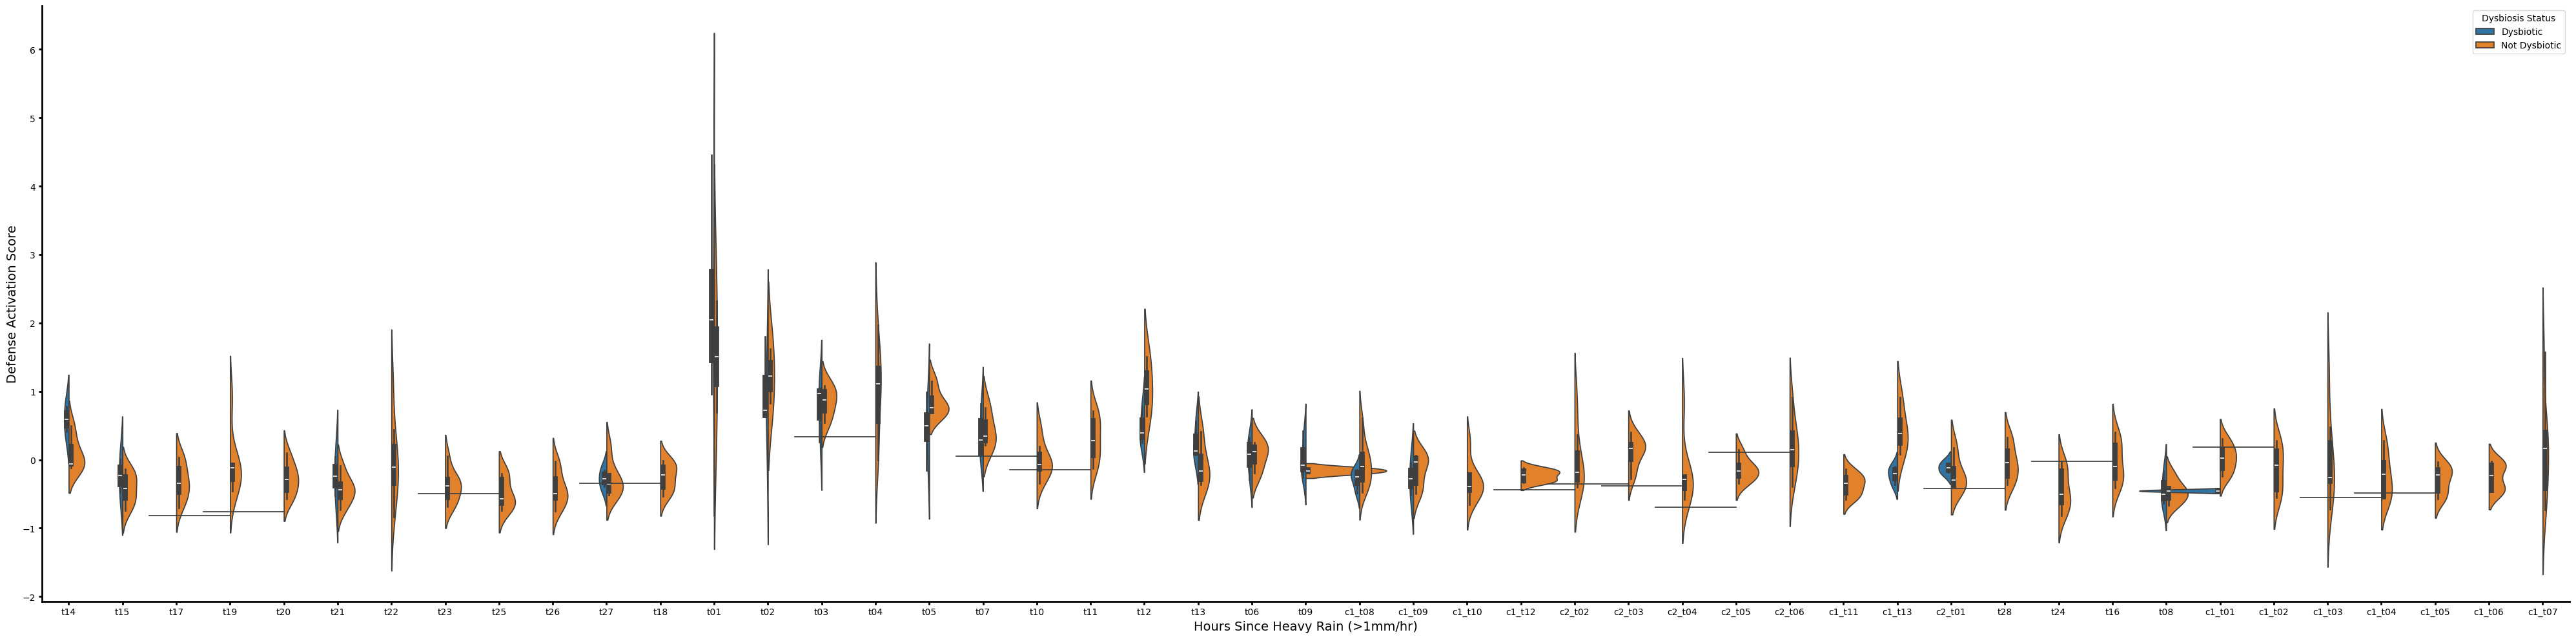

In [66]:
fig, ax = plt.subplots(figsize=(40, 10))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=circadian_metadata_w_load_info,
    x="timepoint",
    y="Summed Defense Z Score",
    hue="Dysbiosis Status",
    width=3,
    split=True,
    inner="box",
)
plt.xlabel("Hours Since Heavy Rain (>1mm/hr)", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')